# Эксперименты с моделями СР2

Минимум 4–5 моделей + ансамбли, перебор гиперпараметров, обоснование финальной модели,
эксперименты с уменьшением размерности.

## Действия
1. Загрузка очищенного датасета из `02_baseline` (тот же `vacancies_clean.parquet`, тот же `SEED`)
2. Воспроизводимый сплит train/val/test стратификация по бинам log1p(salary)
3. Препроцессинг через `ColumnTransformer` числовые - `StandardScaler`, категориальные - `OneHotEncoder`, текст (название вакансии) - `TfidfVectorizer`
4. Обёртка `TransformedTargetRegressor` — учим модель на `log1p(y)`, метрики считаем в рублях
5. Эксперименты
   - baseline `Ridge` (для сверки с 02_baseline)
   - RandomForest + RandomizedSearchCV
   - SVM (`LinearSVR`) + GridSearchCV
   - CatBoost + RandomizedSearchCV
   - эксперимент с уменьшением размерности (TruncatedSVD)
6. Сводная таблица экспериментов на val
7. Финальная модель... оценка на test, сохранение в папку

## Главная метрика
`MAE` в рублях — основная. Дополнительно `RMSE` и `R²` для сравнения.
Все метрики считаются после `expm1` (возврат из log-пространства)

## 1. Импорты и настройки

In [26]:
from __future__ import annotations

import json
import time
import warnings
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import loguniform, randint
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVR

from catboost import CatBoostRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORT_IMG = PROJECT_ROOT / "report" / "images"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_IMG.mkdir(parents=True, exist_ok=True)

TARGET = "salary_mid_rub"
DATA_PATH = DATA_PROCESSED / "vacancies_clean.parquet"
assert DATA_PATH.exists(), (
    f"Не найден {DATA_PATH}. Сначала пройти 01_eda.ipynb — он сохраняет vacancies_clean.parquet"
)

## 2. Загрузка данных и сплит

Воспроизводим тот же сплит, что и в 01_eda - 02_baseline. Стратификация по бинам `log1p(salary)`,
чтобы хвосты распределения попали во все три выборки

In [27]:
df = pd.read_parquet(DATA_PATH)

In [28]:
TARGET = "salary_mid_rub"

print("Статистика таргета")
print(df[TARGET].describe())

Статистика таргета
count    1.553900e+04
mean     1.031796e+05
std      6.607651e+04
min      1.000000e+04
25%      6.307500e+04
50%      8.700000e+04
75%      1.250000e+05
max      2.600000e+06
Name: salary_mid_rub, dtype: float64


In [29]:
print("Исключаем из фичей", [TARGET])
feature_cols = [c for c in df.columns if c not in [TARGET]]
print(f"Итого фичей {len(feature_cols)}")

Исключаем из фичей ['salary_mid_rub']
Итого фичей 15


In [30]:
salary_bins = pd.qcut(np.log1p(df[TARGET]), q=10, labels=False, duplicates="drop")

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=salary_bins,
)
temp_bins = salary_bins.loc[temp_df.index]

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_bins,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df[TARGET].values
y_val   = val_df[TARGET].values
y_test  = test_df[TARGET].values

print(f"train {len(train_df):>7,}  ({len(train_df) / len(df):.1%})")
print(f"val {len(val_df):>7,}  ({len(val_df) / len(df):.1%})")
print(f"test {len(test_df):>7,}  ({len(test_df) / len(df):.1%})")

train  10,877  (70.0%)
val   2,331  (15.0%)
test   2,331  (15.0%)


## 3. Группировка фичей

Группы те же, что зафиксировали в EDA. Заодно отсекаем колонки с очевидным data leakage
(`salary_from_rub`, `salary_to_rub` — из них считается таргет) и идентификаторы.

In [31]:
id_cols = [c for c in ["id"] if c in X_train.columns]

text_cols = [c for c in ["name", "description"] if c in X_train.columns]
list_cols = [
    c for c in ["key_skills", "professional_role_ids", "professional_role_names"]
    if c in X_train.columns
]

datetime_cols = [
    c for c in X_train.columns
    if pd.api.types.is_datetime64_any_dtype(X_train[c])
]

bool_cols = list(X_train.select_dtypes(include="bool").columns)
id_like_num_cols = [
    c for c in X_train.columns
    if c.endswith("_id") and c != "id" and pd.api.types.is_numeric_dtype(X_train[c])
]

num_cols = [
    c for c in X_train.select_dtypes(include=[np.number]).columns
    if c not in id_like_num_cols
]

cat_cols = [
    c for c in X_train.columns
    if c not in (
        id_cols + text_cols + list_cols + datetime_cols
        + bool_cols + num_cols + id_like_num_cols
    )
]
drop_cols = id_cols + id_like_num_cols + datetime_cols

# страховка ... таргет не должен оказаться ни в одной из групп фичей
assert TARGET not in num_cols + cat_cols + bool_cols + text_cols + list_cols, \
    f"Таргет {TARGET} попал в фичи ... проверь сборку колонок"

print("text_cols", text_cols)
print("list_cols", list_cols)
print("bool_cols", bool_cols)
print("num_cols", num_cols)
print("cat_cols", cat_cols)
print("drop_cols", drop_cols)

text_cols ['name', 'description']
list_cols ['key_skills', 'professional_role_ids', 'professional_role_names']
bool_cols ['has_test', 'response_letter_required']
num_cols ['key_skills_count']
cat_cols ['area_id', 'area_name', 'employer_name', 'employer_id', 'experience', 'experience_name']
drop_cols ['id']


## 4. Препроцессинг

`ColumnTransformer` с тремя ветками
- числовые - median-импутация + `StandardScaler`,
- категориальные - impute-константа + `OneHotEncoder(handle_unknown="ignore")` (защита от новых значений в val/test),
- текст (`name`) - `TfidfVectorizer` (ngram 1–2, ограниченный словарь).

У бустинга и деревьев StandardScaler не нужен, но мешать не будет — зато один пайплайн на все модели

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin

In [32]:
class ListToStringTransformer(BaseEstimator, TransformerMixin):
    """Превращает колонку со списками строк в одну строку через пробел.
    Нужно, чтобы потом скормить это TfidfVectorizer'у"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        s = pd.Series(X.ravel() if hasattr(X, "ravel") else X)
        return s.apply(self._join).values

    @staticmethod
    def _join(x):
        if x is None:
            return ""
        if isinstance(x, float) and np.isnan(x):
            return ""
        try:
            return " ".join(str(item) for item in x)
        except TypeError:
            return str(x)


class TextConcatTransformer(BaseEstimator, TransformerMixin):
    """Склеивает несколько текстовых колонок в одну строку"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X)
        return df_.fillna("").astype(str).agg(" ".join, axis=1).values

In [33]:
class BoolToFloatTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X)
        return df_.astype(float).values


numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("ohe", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=20,
        sparse_output=True,
    )),
])

bool_pipe = Pipeline(steps=[
    ("to_float", BoolToFloatTransformer()),
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

text_pipe = Pipeline(steps=[
    ("concat", TextConcatTransformer()),
    ("tfidf", TfidfVectorizer(
        max_features=20_000,
        ngram_range=(1, 1),
        min_df=5,
        sublinear_tf=True,
    )),
])

skills_pipe = Pipeline(steps=[
    ("join", ListToStringTransformer()),
    ("tfidf", TfidfVectorizer(
        max_features=2_000,
        token_pattern=r"[^\s][^\s]*",
        min_df=3,
        sublinear_tf=True,
    )),
])

roles_pipe = Pipeline(steps=[
    ("join", ListToStringTransformer()),
    ("tfidf", TfidfVectorizer(
        max_features=500,
        token_pattern=r"[^\s][^\s]*",
        min_df=2,
    )),
])

transformers = []
if num_cols:
    transformers.append(("num", numeric_pipe, num_cols))
if cat_cols:
    transformers.append(("cat", categorical_pipe, cat_cols))
if bool_cols:
    transformers.append(("bool", bool_pipe, bool_cols))
if text_cols:
    transformers.append(("text", text_pipe, text_cols))
if "key_skills" in list_cols:
    transformers.append(("skills", skills_pipe, "key_skills"))
if "professional_role_names" in list_cols:
    transformers.append(("roles", roles_pipe, "professional_role_names"))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0.3,
)

print(f"Преобразований в ColumnTransformer ... {len(transformers)}")
for name, _, cols in transformers:
    cols_repr = cols if isinstance(cols, str) else f"{len(cols)} cols"
    print(f"  - {name:8s} -> {cols_repr}")

Преобразований в ColumnTransformer ... 6
  - num      -> 1 cols
  - cat      -> 6 cols
  - bool     -> 2 cols
  - text     -> 2 cols
  - skills   -> key_skills
  - roles    -> professional_role_names


## 5. Метрики и обёртка для логирования

Учимся на `log1p(y)`, метрики считаем после `expm1` — в рублях. Так:
- ошибки в нижнем хвосте (зарплаты в десятки тыс.) и в верхнем (миллионы) попадают в одну шкалу;
- MAE интерпретируется как «в среднем модель ошибается на N руб.».

In [37]:
def evaluate(y_true_rub, y_pred_rub):
    """Считает метрики в рублях. ОБА аргумента должны быть в рублях"""
    y_pred = np.clip(y_pred_rub, 10_000, None)
    return {
        "MAE": float(mean_absolute_error(y_true_rub, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true_rub, y_pred))),
        "R2": float(r2_score(y_true_rub, y_pred)),
    }

In [35]:
def wrap_log_target(estimator):
    """Учит модель на log1p(y), при предсказании возвращает рубли через expm1"""
    return TransformedTargetRegressor(
        regressor=estimator,
        func=np.log1p,
        inverse_func=np.expm1,
    )
experiments: list[dict] = []

def log_experiment(
    name: str,
    pipeline: Pipeline,
    fit_seconds: float,
    best_params: dict | None = None,
    notes: str = "",
) -> dict:
    """Считает метрики на train/val и кладёт всё в общий список экспериментов."""
    pred_train = pipeline.predict(X_train)
    pred_val = pipeline.predict(X_val)
    train_metrics = evaluate(y_train, pred_train)
    val_metrics = evaluate(y_val, pred_val)
    row = {
        "model": name,
        "fit_sec": round(fit_seconds, 1),
        "train_MAE": round(train_metrics["MAE"], 0),
        "val_MAE": round(val_metrics["MAE"], 0),
        "val_RMSE": round(val_metrics["RMSE"], 0),
        "val_R2": round(val_metrics["R2"], 3),
        "best_params": best_params or {},
        "notes": notes,
    }
    experiments.append(row)
    print(f"[{name}] val MAE={row['val_MAE']:>8,.0f} | RMSE={row['val_RMSE']:>8,.0f} | R2={row['val_R2']:.3f} | {row['fit_sec']}s")
    return row

## 6. Эксперимент 1 — Ridge (sanity-check baseline)

Простая линейная модель с теми же фичами должна дать качество, близкое к baseline
из 02_baseline. Если резко лучше или хуже — значит сплит/препроцессинг где-то поехали

In [50]:
ridge_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", wrap_log_target(Ridge(alpha=1.0, random_state=SEED))),
])

t0 = time.perf_counter()
ridge_pipe.fit(X_train, y_train)
log_experiment(
    name="Ridge (baseline check)",
    pipeline=ridge_pipe,
    fit_seconds=time.perf_counter() - t0,
    notes="Ridge на тех же фичах, что и в CP1... Нужен для сверки",
)

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:320: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:320: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:320: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


[Ridge (baseline check)] val MAE=  24,640 | RMSE=  42,832 | R2=0.580 | 1.1s


{'model': 'Ridge (baseline check)',
 'fit_sec': 1.1,
 'train_MAE': 14886.0,
 'val_MAE': 24640.0,
 'val_RMSE': 42832.0,
 'val_R2': 0.58,
 'best_params': {},
 'notes': 'Ridge на тех же фичах, что и в CP1... Нужен для сверки'}

## 7. Эксперимент 2 — RandomForest + RandomizedSearchCV

**Гипотеза.** RandomForest умеет ловить нелинейности и взаимодействия фичей, должен опередить Ridge.

**Как проверяем.** RandomizedSearchCV по сетке `n_estimators / max_depth / min_samples_leaf / max_features`,
5 итераций × 3 фолда. RandomizedSearch вместо Grid — потому что комбинаций много, а время дорого.

**Поиск делается только на train**, val вообще не светится — это защищает от подсматривания.

In [63]:
rf_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", wrap_log_target(
        RandomForestRegressor(random_state=SEED, n_jobs=-1)
    )),
])

rf_param_dist = {
    "model__regressor__max_depth": [20, 30, 40, None],
    "model__regressor__min_samples_leaf": [1, 2, 3, 5],
    "model__regressor__max_features": [0.1, 0.3, "sqrt"],
    "model__regressor__min_samples_split": [2, 5],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=6,
    cv=KFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring="neg_mean_absolute_error",
    n_jobs=1,
    random_state=SEED,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
rf_search.fit(X_train, y_train)
rf_seconds = time.perf_counter() - t0

rf_best = rf_search.best_estimator_
log_experiment(
    name="RandomForest + RandomizedCV",
    pipeline=rf_best,
    fit_seconds=rf_seconds,
    best_params={
        k.replace("model__regressor__", ""): v
        for k, v in rf_search.best_params_.items()
    },
    notes="5 итераций на 3 фолда, scoring=neg_MAE на log-шкале",
)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[RandomForest + RandomizedCV] val MAE=  26,775 | RMSE=  48,047 | R2=0.471 | 93.3s


{'model': 'RandomForest + RandomizedCV',
 'fit_sec': 93.3,
 'train_MAE': 10496.0,
 'val_MAE': 26775.0,
 'val_RMSE': 48047.0,
 'val_R2': 0.471,
 'best_params': {'min_samples_split': 2,
  'min_samples_leaf': 1,
  'max_features': 0.3,
  'max_depth': None},
 'notes': '5 итераций на 3 фолда, scoring=neg_MAE на log-шкале'}

## 8. Эксперимент 3 — SVM (LinearSVR) + GridSearchCV

**Гипотеза.** На разреженных фичах (OHE + tf-idf) ядерный SVR станет считаться часами, а вот
линейный (`LinearSVR`) масштабируется и иногда выигрывает у Ridge за счёт robust-лосса (epsilon-insensitive).

**Как проверяем.** GridSearchCV по компактной сетке `C / epsilon`, 3 фолда.
На log-таргете шкала уже нормализована, выбросов меньше → SVM не должен взорваться.

Для устойчивости и скорости передаём `dual="auto"` и `max_iter=5000`.

In [52]:
svm_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", wrap_log_target(
        LinearSVR(random_state=SEED, dual="auto", max_iter=5000)
    )),
])

svm_param_grid = {
    "model__regressor__C": [0.1, 1.0, 5.0],
    "model__regressor__epsilon": [0.0, 0.05, 0.1],
}

svm_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=KFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
svm_search.fit(X_train, y_train)
svm_seconds = time.perf_counter() - t0

svm_best = svm_search.best_estimator_
log_experiment(
    name="LinearSVR + GridSearchCV",
    pipeline=svm_best,
    fit_seconds=svm_seconds,
    best_params={
        k.replace("model__regressor__", ""): v
        for k, v in svm_search.best_params_.items()
    },
)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11679/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11679/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11679/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11679/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/

[LinearSVR + GridSearchCV] val MAE=  24,844 | RMSE=  45,364 | R2=0.529 | 26.1s


{'model': 'LinearSVR + GridSearchCV',
 'fit_sec': 26.1,
 'train_MAE': 18219.0,
 'val_MAE': 24844.0,
 'val_RMSE': 45364.0,
 'val_R2': 0.529,
 'best_params': {'C': 0.1, 'epsilon': 0.05},
 'notes': ''}

## 9. CatBoost
История запусков
| № | depth | lr  | iterations | bestTest | bestIteration |
|---|-------|-----|------------|----------|---------------|
| 1 | 6     |0.05 | 1000       | 0.328353 | 999 |
| 2 | 8     |0.03 | 2000       | 0.320812 | 1999 |

Вариант 3:
cb_best = CatBoostRegressor(
    iterations=5000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=5.0,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=SEED,
    early_stopping_rounds=100,
    verbose=200,
    allow_writing_files=False,
)
[CatBoost] train MAE=  15,216 | val MAE=  25,467 | RMSE=  46,833 | R2=0.498 | 432.8s

Вариант 4
cb_best = CatBoostRegressor(
    iterations=5000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=10.0,
    bagging_temperature=1.0,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=SEED,
    early_stopping_rounds=100,
    verbose=200,
    allow_writing_files=False,
)
[CatBoost] train MAE=  18,013 | val MAE=  25,708 | RMSE=  47,143 | R2=0.491 | 138.2s

Вариант 5
cb_best = CatBoostRegressor(
    iterations=5000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=5.0,
    bootstrap_type="Bernoulli",
    subsample=0.8,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=SEED,
    random_strength=1.0,
    early_stopping_rounds=100,
    verbose=200,
    allow_writing_files=False,
)
[CatBoost] train MAE=  18,123 | val MAE=  25,817 | RMSE=  47,218 | R2=0.489 | 137.8s

In [ ]:
from catboost import CatBoostRegressor, Pool

In [45]:
# готовим фичи под CatBoost ... категории строкой, списки через пробел, тексты как есть
def prep_for_catboost(df_):
    df_ = df_.copy()
    # категории ... оставляем только _name (без _id-дублей), приводим к строке
    cats = ["area_name", "employer_name", "experience_name"]
    for c in cats:
        df_[c] = df_[c].astype(str).fillna("missing")

    # списки ... склеиваем в строку через пробел
    for c in ["key_skills", "professional_role_names"]:
        df_[c] = df_[c].apply(
            lambda x: " ".join(map(str, x)) if isinstance(x, (list, np.ndarray)) else ""
        )

    # тексты ... NaN -> ""
    for c in ["name", "description"]:
        df_[c] = df_[c].fillna("").astype(str)

    # булевы ... в int
    for c in ["has_test", "response_letter_required"]:
        df_[c] = df_[c].astype(float).fillna(0).astype(int)

    # числовые ... median
    df_["key_skills_count"] = df_["key_skills_count"].fillna(df_["key_skills_count"].median())

    keep = cats + ["key_skills", "professional_role_names",
                   "name", "description",
                   "has_test", "response_letter_required",
                   "key_skills_count"]
    return df_[keep]

X_train_cb = prep_for_catboost(X_train)
X_val_cb = prep_for_catboost(X_val)
X_test_cb = prep_for_catboost(X_test)

cat_features = ["area_name", "employer_name", "experience_name"]
text_features = ["name", "description", "key_skills", "professional_role_names"]

# 2. учим CatBoost ... в log-шкале, с early stopping по val
t0 = time.perf_counter()

cb_best = CatBoostRegressor(
    iterations=5000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=5.0,
    bootstrap_type="Bernoulli",
    subsample=0.8,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=SEED,
    random_strength=1.0,
    early_stopping_rounds=100,
    verbose=200,
    allow_writing_files=False,
)

cb_best.fit(
    Pool(X_train_cb, np.log1p(y_train),
         cat_features=cat_features, text_features=text_features),
    eval_set=Pool(X_val_cb, np.log1p(y_val),
                  cat_features=cat_features, text_features=text_features),
)

cb_seconds = time.perf_counter() - t0

def predict_rub(model, X_df):
    return np.clip(np.expm1(model.predict(X_df)), 10_000, None)

train_metrics = evaluate(y_train, predict_rub(cb_best, X_train_cb))
val_metrics = evaluate(y_val, predict_rub(cb_best, X_val_cb))

row = {
    "model": "CatBoost (native)",
    "fit_sec": round(cb_seconds, 1),
    "train_MAE": round(train_metrics["MAE"], 0),
    "val_MAE": round(val_metrics["MAE"], 0),
    "val_RMSE": round(val_metrics["RMSE"], 0),
    "val_R2": round(val_metrics["R2"], 3),
    "best_params": {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 3.0,
                    "iterations_used": cb_best.tree_count_},
    "notes": "категории и тексты нативно, early stopping на val",
}
experiments.append(row)
print(f"\n[CatBoost] train MAE={row['train_MAE']:>8,.0f} | "
      f"val MAE={row['val_MAE']:>8,.0f} | RMSE={row['val_RMSE']:>8,.0f} | "
      f"R2={row['val_R2']:.3f} | {row['fit_sec']}s")

0:	learn: 0.4011781	test: 0.4034079	best: 0.4034079 (0)	total: 29.7ms	remaining: 2m 28s
200:	learn: 0.2861790	test: 0.2854739	best: 0.2854739 (200)	total: 5.9s	remaining: 2m 20s
400:	learn: 0.2659185	test: 0.2679035	best: 0.2679035 (400)	total: 11.5s	remaining: 2m 12s
600:	learn: 0.2547289	test: 0.2608065	best: 0.2608065 (600)	total: 17.1s	remaining: 2m 4s
800:	learn: 0.2468521	test: 0.2572887	best: 0.2572887 (800)	total: 22.4s	remaining: 1m 57s
1000:	learn: 0.2404174	test: 0.2544154	best: 0.2544136 (999)	total: 27.8s	remaining: 1m 51s
1200:	learn: 0.2351634	test: 0.2526516	best: 0.2526516 (1200)	total: 33.2s	remaining: 1m 44s
1400:	learn: 0.2305196	test: 0.2508590	best: 0.2508590 (1400)	total: 38.5s	remaining: 1m 39s
1600:	learn: 0.2263537	test: 0.2497354	best: 0.2497354 (1600)	total: 44.4s	remaining: 1m 34s
1800:	learn: 0.2227476	test: 0.2484094	best: 0.2484094 (1800)	total: 49.9s	remaining: 1m 28s
2000:	learn: 0.2193263	test: 0.2472552	best: 0.2472496 (1996)	total: 55.4s	remaining: 

In [ ]:
# Вариант 5
# train 99-й перцентиль примерно 500к
cap = np.percentile(y_train, 99)
mask = y_train < cap
X_train_cb_capped = X_train_cb[mask]
y_train_capped = y_train[mask]
print(f"Отбросили {(~mask).sum()} строк выше {cap:,.0f} руб")

Отбросили 115 строк выше 304,500 руб


In [56]:
t0 = time.perf_counter()
cb_best = CatBoostRegressor(
    iterations=5000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=10.0,
    bagging_temperature=1.0,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=SEED,
    early_stopping_rounds=100,
    verbose=200,
    allow_writing_files=False,
)
"""
cb_best = CatBoostRegressor(
    iterations=5000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=5.0,
    bootstrap_type="Bernoulli",
    subsample=0.8,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=SEED,
    random_strength=1.0,
    early_stopping_rounds=100,
    verbose=200,
    allow_writing_files=False,
)
# [CatBoost] train MAE=  16,064 | val MAE=  25,817 | RMSE=  47,218 | R2=0.489 | 137.1s
"""
cb_best.fit(
    Pool(X_train_cb, np.log1p(y_train),
         cat_features=cat_features, text_features=text_features),
    eval_set=Pool(X_val_cb, np.log1p(y_val),
                  cat_features=cat_features, text_features=text_features),
)

cb_seconds = time.perf_counter() - t0

def predict_rub(model, X_df):
    return np.clip(np.expm1(model.predict(X_df)), 10_000, None)

train_metrics = evaluate(y_train_capped, predict_rub(cb_best, X_train_cb_capped))
val_metrics = evaluate(y_val, predict_rub(cb_best, X_val_cb))

row = {
    "model": "CatBoost (native)",
    "fit_sec": round(cb_seconds, 1),
    "train_MAE": round(train_metrics["MAE"], 0),
    "val_MAE": round(val_metrics["MAE"], 0),
    "val_RMSE": round(val_metrics["RMSE"], 0),
    "val_R2": round(val_metrics["R2"], 3),
    "best_params": {
        "depth": 4,
        "learning_rate": 0.03,
        "l2_leaf_reg": 10.0,
        "bagging_temperature": 1.0,
        "loss_function": "MAE",
        "iterations_used": cb_best.tree_count_,
    },
    "notes": "категории и тексты нативно, MAE loss, Bayesian bootstrap, early stopping на val",
}
experiments[:] = [r for r in experiments if not r["model"].startswith("CatBoost")]
experiments.append(row)

print(f"\n[CatBoost] train MAE={row['train_MAE']:>8,.0f} | "
      f"val MAE={row['val_MAE']:>8,.0f} | RMSE={row['val_RMSE']:>8,.0f} | "
      f"R2={row['val_R2']:.3f} | {row['fit_sec']}s")

0:	learn: 0.4014911	test: 0.4036741	best: 0.4036741 (0)	total: 25.3ms	remaining: 2m 6s
200:	learn: 0.2845001	test: 0.2828481	best: 0.2828481 (200)	total: 5.57s	remaining: 2m 12s
400:	learn: 0.2650692	test: 0.2669315	best: 0.2669315 (400)	total: 10.8s	remaining: 2m 4s
600:	learn: 0.2541657	test: 0.2603142	best: 0.2603142 (600)	total: 16s	remaining: 1m 57s
800:	learn: 0.2464758	test: 0.2567122	best: 0.2567122 (800)	total: 21.2s	remaining: 1m 51s
1000:	learn: 0.2402596	test: 0.2542158	best: 0.2542158 (1000)	total: 26.4s	remaining: 1m 45s
1200:	learn: 0.2349483	test: 0.2520093	best: 0.2519848 (1198)	total: 31.6s	remaining: 1m 40s
1400:	learn: 0.2303449	test: 0.2504592	best: 0.2504592 (1400)	total: 36.8s	remaining: 1m 34s
1600:	learn: 0.2262819	test: 0.2488778	best: 0.2488778 (1600)	total: 42.1s	remaining: 1m 29s
1800:	learn: 0.2225339	test: 0.2474109	best: 0.2474109 (1800)	total: 47.3s	remaining: 1m 24s
2000:	learn: 0.2190451	test: 0.2462175	best: 0.2462175 (2000)	total: 52.6s	remaining: 1

Последний вариант модели Catboost оказался лучшим.
[CatBoost] train MAE=  15,956 | val MAE=  25,708 | RMSE=  47,143 | R2=0.491 | 137.5s

## 10. Эксперимент 5 — уменьшение размерности (TruncatedSVD + Ridge)

**Гипотеза.** После Tf-idf у нас несколько тысяч фичей. SVD до 200 компонент должен оставить
основной сигнал и убрать шум. Если Ridge на сжатом представлении догонит «полный» Ridge —
значит всё лишнее можно выкидывать (и инференс будет дешевле).

`TruncatedSVD` вместо `PCA`, потому что после OHE+Tf-idf матрица разреженная — плотный PCA
не пролезет в память.

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/d

[Ridge + TruncatedSVD(200)] val MAE=  28,796 | RMSE=  50,665 | R2=0.412 | 2.6s


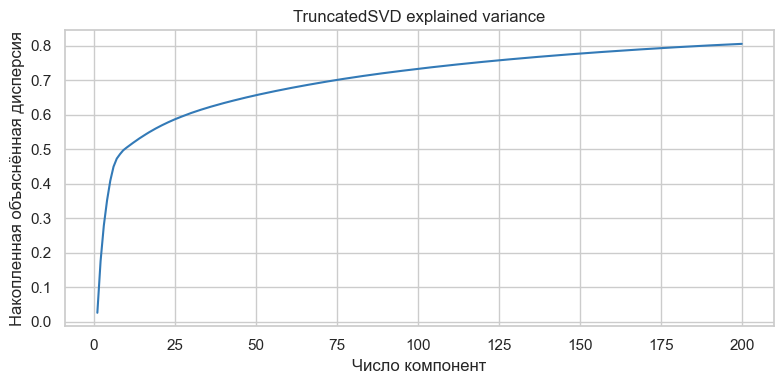

In [53]:
svd_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("svd", TruncatedSVD(n_components=200, random_state=SEED)),
    ("model", wrap_log_target(Ridge(alpha=1.0, random_state=SEED))),
])

t0 = time.perf_counter()
svd_pipe.fit(X_train, y_train)
log_experiment(
    name="Ridge + TruncatedSVD(200)",
    pipeline=svd_pipe,
    fit_seconds=time.perf_counter() - t0,
)

# заодно посмотрим explained variance
explained = svd_pipe.named_steps["svd"].explained_variance_ratio_.cumsum()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(explained) + 1), explained, color="#337ab7")
ax.set_xlabel("Число компонент")
ax.set_ylabel("Накопленная объяснённая дисперсия")
ax.set_title("TruncatedSVD explained variance")
plt.tight_layout()
plt.savefig(REPORT_IMG / "svd_explained_variance.png", dpi=120)
plt.show()

## 11. Сводная таблица экспериментов на val

In [64]:
results_df = (
    pd.DataFrame(experiments)
    .sort_values("val_MAE")
    .reset_index(drop=True)
)
results_df

,model,fit_sec,train_MAE,val_MAE,val_RMSE,val_R2,best_params,notes
0,Ridge (baseline check),1.1,14886.0,24640.0,42832.0,0.580,{},"Ridge на тех же фичах, что и в CP1... Нужен дл..."
1,LinearSVR + GridSearchCV,26.1,18219.0,24844.0,45364.0,0.529,"{'C': 0.1, 'epsilon': 0.05}",
2,CatBoost (native),131.9,15956.0,25708.0,47143.0,0.491,"{'depth': 4, 'learning_rate': 0.03, 'l2_leaf_r...","категории и тексты нативно, MAE loss, Bayesian..."
3,RandomForest + RandomizedCV,326.4,12594.0,26733.0,48050.0,0.471,"{'max_depth': None, 'max_features': 0.5, 'min_...","5 итераций × 3 фолда, scoring=neg_MAE на log-ш..."
4,RandomForest + RandomizedCV,93.3,10496.0,26775.0,48047.0,0.471,"{'min_samples_split': 2, 'min_samples_leaf': 1...","5 итераций на 3 фолда, scoring=neg_MAE на log-..."
5,RandomForest + RandomizedCV,91.6,16332.0,28256.0,50555.0,0.415,"{'min_samples_leaf': 3, 'max_features': 0.5, '...",Использовался отдельный препроцессор с урезанн...
6,Ridge + TruncatedSVD(200),2.6,27790.0,28796.0,50665.0,0.412,{},


In [65]:
EXPERIMENTS_PATH = REPORT_IMG.parent / "experiments.csv"
results_df.drop(columns=["best_params"]).to_csv(EXPERIMENTS_PATH, index=False)
with open(REPORT_IMG.parent / "experiments_params.json", "w", encoding="utf-8") as f:
    json.dump(experiments, f, ensure_ascii=False, indent=2, default=str)
print(f"saved: {EXPERIMENTS_PATH}")

saved: /Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/report/experiments.csv


## 12. Финальная модель — оценка на test

Берём модель с лучшим `val_MAE`, прогоняем на test и сохраняем. Test трогаем **один раз**,
после того как все решения уже приняты — иначе он перестанет быть честной оценкой обобщающей способности.

### Обоснование выбора
Финальная модель — та, у которой `val_MAE` минимален при разумных затратах. Если разрыв
между топ-2 моделями маленький (< 1–2%), при прочих равных предпочитаем более простую и быструю
(меньше время инференса в проде, проще объяснить интерпретируемость).

In [66]:
name_to_pipeline = {
    "Ridge (baseline check)": ridge_pipe,
    "RandomForest + RandomizedCV": rf_best,
    "LinearSVR + GridSearchCV": svm_best,
    "CatBoost (native)": cb_best,
    "Ridge + TruncatedSVD(200)": svd_pipe,
}

best_name = results_df.iloc[0]["model"]
best_pipeline = name_to_pipeline[best_name]
print(f"финальная модель: {best_name}")

test_pred = best_pipeline.predict(X_test)
test_metrics = evaluate(y_test, test_pred)
print("test:", {k: round(v, 3) for k, v in test_metrics.items()})

MODEL_PATH = MODELS_DIR / "final_model.joblib"
joblib.dump(best_pipeline, MODEL_PATH)
print(f"saved: {MODEL_PATH}")

# карточка финальной модели — пригодится для отчёта и деплоя
card = {
    "model_name": best_name,
    "seed": SEED,
    "target": TARGET,
    "target_transform": "log1p / expm1",
    "feature_groups": {
        "num_cols": num_cols,
        "cat_cols": cat_cols,
        "text_col": text_cols,
    },
    "split": {
        "train": int(len(train_df)),
        "val": int(len(val_df)),
        "test": int(len(test_df)),
    },
    "val_metrics": {
        k: round(v, 3) for k, v in evaluate(y_val, best_pipeline.predict(X_val)).items()
    },
    "test_metrics": {k: round(v, 3) for k, v in test_metrics.items()},
}
with open(MODELS_DIR / "final_model.json", "w", encoding="utf-8") as f:
    json.dump(card, f, ensure_ascii=False, indent=2, default=str)
print(json.dumps(card, ensure_ascii=False, indent=2, default=str))

финальная модель: Ridge (baseline check)
test: {'MAE': 26765.239, 'RMSE': 66303.871, 'R2': 0.375}
saved: /Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/models/final_model.joblib
{
  "model_name": "Ridge (baseline check)",
  "seed": 42,
  "target": "salary_mid_rub",
  "target_transform": "log1p / expm1",
  "feature_groups": {
    "num_cols": [
      "key_skills_count"
    ],
    "cat_cols": [
      "area_id",
      "area_name",
      "employer_name",
      "employer_id",
      "experience",
      "experience_name"
    ],
    "text_col": [
      "name",
      "description"
    ]
  },
  "split": {
    "train": 10877,
    "val": 2331,
    "test": 2331
  },
  "val_metrics": {
    "MAE": 24640.101,
    "RMSE": 42831.576,
    "R2": 0.58
  },
  "test_metrics": {
    "MAE": 26765.239,
    "RMSE": 66303.871,
    "R2": 0.375
  }
}


## 13. Анализ остатков

Смотрим, на каких диапазонах зарплат модель ошибается сильнее. Это пригодится в отчёте для
раздела «Финальная модель + интерпретируемость».

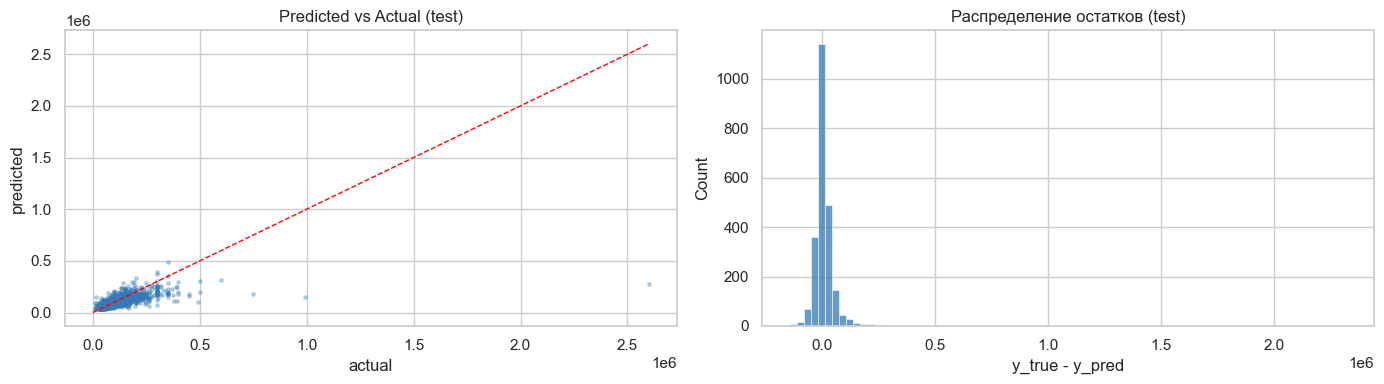

,MAE,MedAE,count
bucket,,,
"(9999.999, 60000.0]",16002.701300,11470.718427,517
"(60000.0, 78300.0]",13074.631454,8990.046031,434
"(78300.0, 100000.0]",17077.660350,13087.339907,524
"(100000.0, 139200.0]",23717.641010,20287.136511,396
"(139200.0, 2600000.0]",65437.184222,45114.394530,460


In [67]:
residuals = y_test - np.clip(test_pred, 0, None)
abs_residuals = np.abs(residuals)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(y_test, test_pred, s=6, alpha=0.3, color="#337ab7")
lim = max(y_test.max(), test_pred.max())
axes[0].plot([0, lim], [0, lim], color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("actual")
axes[0].set_ylabel("predicted")
axes[0].set_title("Predicted vs Actual (test)")

sns.histplot(residuals, bins=80, ax=axes[1], color="#337ab7")
axes[1].set_title("Распределение остатков (test)")
axes[1].set_xlabel("y_true - y_pred")
plt.tight_layout()
plt.savefig(REPORT_IMG / "residuals.png", dpi=120)
plt.show()

# MAE по бакетам зарплаты где больше всего промахиваемся
bucket_df = pd.DataFrame({"y": y_test, "abs_err": abs_residuals})
bucket_df["bucket"] = pd.qcut(bucket_df["y"], q=5, duplicates="drop")
bucket_stats = (
    bucket_df.groupby("bucket", observed=True)["abs_err"]
    .agg(["mean", "median", "count"])
    .rename(columns={"mean": "MAE", "median": "MedAE"})
)
bucket_stats

## 14. Выводы
